#JoshaLynn Worth

#04.13.2026

In [98]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#Part A random seed
np.random.seed(67)

In [99]:
#Read in the datase

df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


#Part A

In [100]:
#Taking the radnom sample of 25
sample_glucose = df.sample(n=25, random_state=67)

In [101]:
#Find highest glucose and mena glucose of this sample
sample_mean = sample_glucose["Glucose"].mean()
sample_max = sample_glucose["Glucose"].max()

In [102]:
# Population stats
pop_mean = df["Glucose"].mean()
pop_max = df["Glucose"].max()

In [103]:
print("Sample Mean=>", sample_mean)
print("Sample Max=>", sample_max)
print("Population Mean=>", pop_mean)
print("Population Max=>", pop_max)

Sample Mean=> 118.96
Sample Max=> 189
Population Mean=> 120.89453125
Population Max=> 199


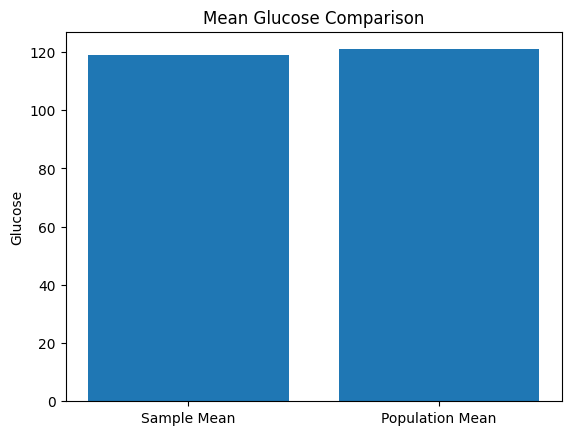

In [104]:
#Compare the means
plt.figure()
plt.bar(["Sample Mean", "Population Mean"], [sample_mean, pop_mean])
plt.title("Mean Glucose Comparison")
plt.ylabel("Glucose")
plt.show()

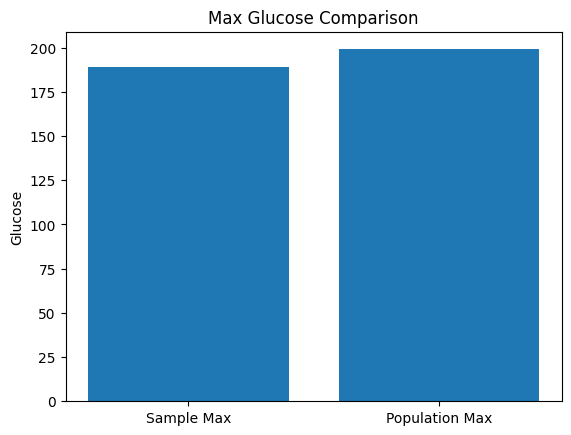

In [105]:
#compare the max
plt.show()
plt.figure()
plt.bar(["Sample Max", "Population Max"], [sample_max, pop_max])
plt.title("Max Glucose Comparison")
plt.ylabel("Glucose")
plt.show()

#Part B

In [106]:
# 98th percentile (sample)
sample_pop = sample_glucose["BMI"].quantile(0.98)

# 98th percentile (population)
pop = df["BMI"].quantile(0.98)

print("Sample 98th Percentile BMI:", sample_pop)
print("Population 98th Percentile BMI:", pop)

Sample 98th Percentile BMI: 45.06
Population 98th Percentile BMI: 47.52599999999996


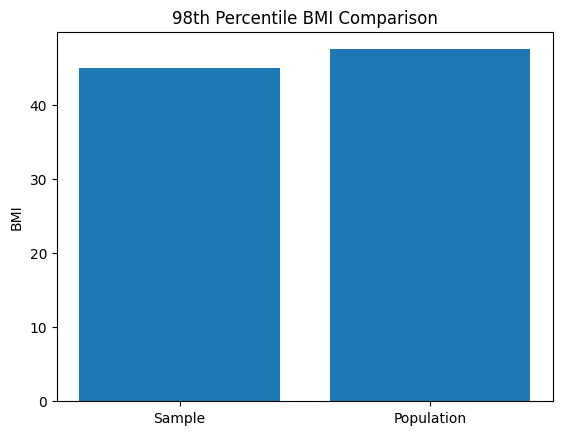

In [107]:
plt.figure()
plt.bar(["Sample", "Population"], [sample_pop, pop])
plt.title("98th Percentile BMI Comparison")
plt.ylabel("BMI")
plt.show()

#Part C

In [108]:
#before we mess wiht the blood pressure we wanna eb sure we dont have missing vlaues
bp = df["BloodPressure"].dropna()

In [109]:
#population statistics mean std and population
pop_mean = bp.mean()
pop_std = bp.std()
pop = bp.quantile(0.98)

In [110]:
#500 samples 150 obs each
n_bootstrap = 500
sample_size = 150

bootstrap_means = []
bootstrap_stds = []
bootstrap_pop = []

for i in range(n_bootstrap):
    sample = bp.sample(n=sample_size, replace=True)

    bootstrap_means.append(sample.mean())
    bootstrap_stds.append(sample.std())
    bootstrap_pop.append(sample.quantile(0.98))

In [111]:
avg_boot_mean = np.mean(bootstrap_means)
avg_boot_std = np.mean(bootstrap_stds)
avg_boot_pop = np.mean(bootstrap_pop)

print(avg_boot_mean, avg_boot_std, avg_boot_pop)

69.11150666666666 19.20662825792674 98.10868000000002


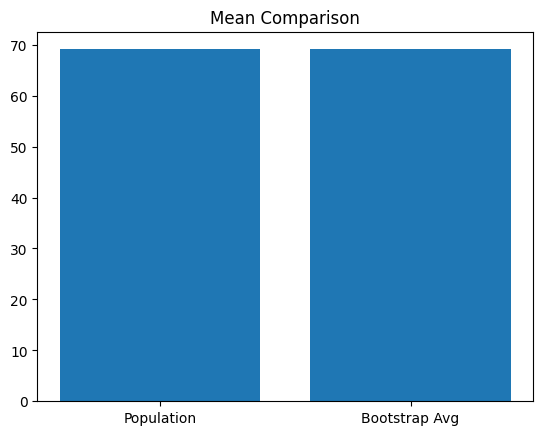

In [112]:
# Mean
plt.figure()
plt.bar(["Population", "Bootstrap Avg"], [pop_mean, avg_boot_mean])
plt.title("Mean Comparison")
plt.show()

**Reporting my findings**
So it looks like the mean in the populaiton and the bootstrap average is super close to see a differnce I would need to print the vlaues and not see charts.

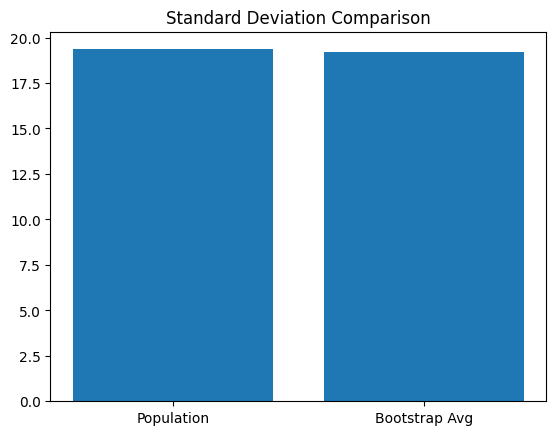

In [113]:
# Std Dev
plt.figure()
plt.bar(["Population", "Bootstrap Avg"], [pop_std, avg_boot_std])
plt.title("Standard Deviation Comparison")
plt.show()

**Report Findings**
The Popuation SD is a tiny bit higer than the boostrap but they are still close

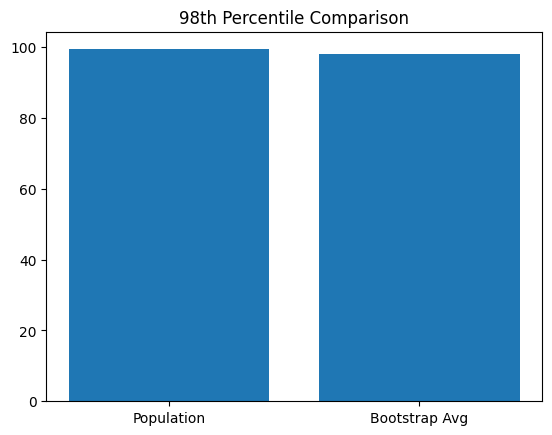

In [114]:
# Percentile
plt.figure()
plt.bar(["Population", "Bootstrap Avg"], [pop, avg_boot_pop])
plt.title("98th Percentile Comparison")
plt.show()

**Report findings**
The 98 percentile pouliton is higher than bootsrtap Avg

#Overall Findings
Bootstrapping lets us get more from the dataset. The bootstrap results were close to the population values, especially for the mean, showing the samples stay consistent with the full dataset. Overall, I felt this showed it is a good way to represent the dataset as a whole.